In [7]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [8]:
from train.train_real import run
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.evaluation.visualizations import plot_profile, plot_profile_markers

from DNAnet.preprocessing.standardize import Standardizer
from DNAnet.preprocessing.drc import DynamicRangeCompress
from DNAnet.preprocessing.pipeline import PreprocessingPipeline

In [9]:
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
gf_path = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/C07_RD14-0003-30_31_32_33_34-1,1,1,1,1-M1e-0.315GF-Q1.9_03.5sec.hid'
gf_path_2 = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021516ADG_5sec)/D01_RD14-0003-44_45-1,1-M4U15-0.03GF-Q1.3_04.5sec.hid'
gf_path_3 = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/E44_RD14-0003-33_34-1,2-M4d-0.045GF-Q1.3_05.5sec.hid'
gf_path_4 = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021716ADG_5sec)/G03_RD14-0003-40_41-1,4-M3e-0.625GF-Q0.8_07.5sec.hid'
local_gf_path = 'resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'

image = HIDImage(
    path=local_gf_path,
    panel=Panel(gf_panel_path),
    size_standard="GENESCAN_600_LIZ",
    include_size_standard=True
)

print(image.data.shape)
data = image.data.squeeze()

(6, 4096, 1)


In [10]:
preprocessing_steps = PreprocessingPipeline([
    # Standardizer(per_dye=True, axis=1),
    DynamicRangeCompress(method='log', factor=1)
])
preprocessing_steps.to_config()

[{'name': 'DynamicRangeCompress', 'params': {'method': 'log', 'factor': 1}}]

In [11]:
# scaler = Standardizer(per_dye=True, axis=1)
# standardized_data = scaler.fit_transform(data)

# scaler.mean_, scaler.std_

# compressor = DynamicRangeCompress(method='tanh', factor=1)
# compressed_data = compressor.fit_transform(standardized_data)

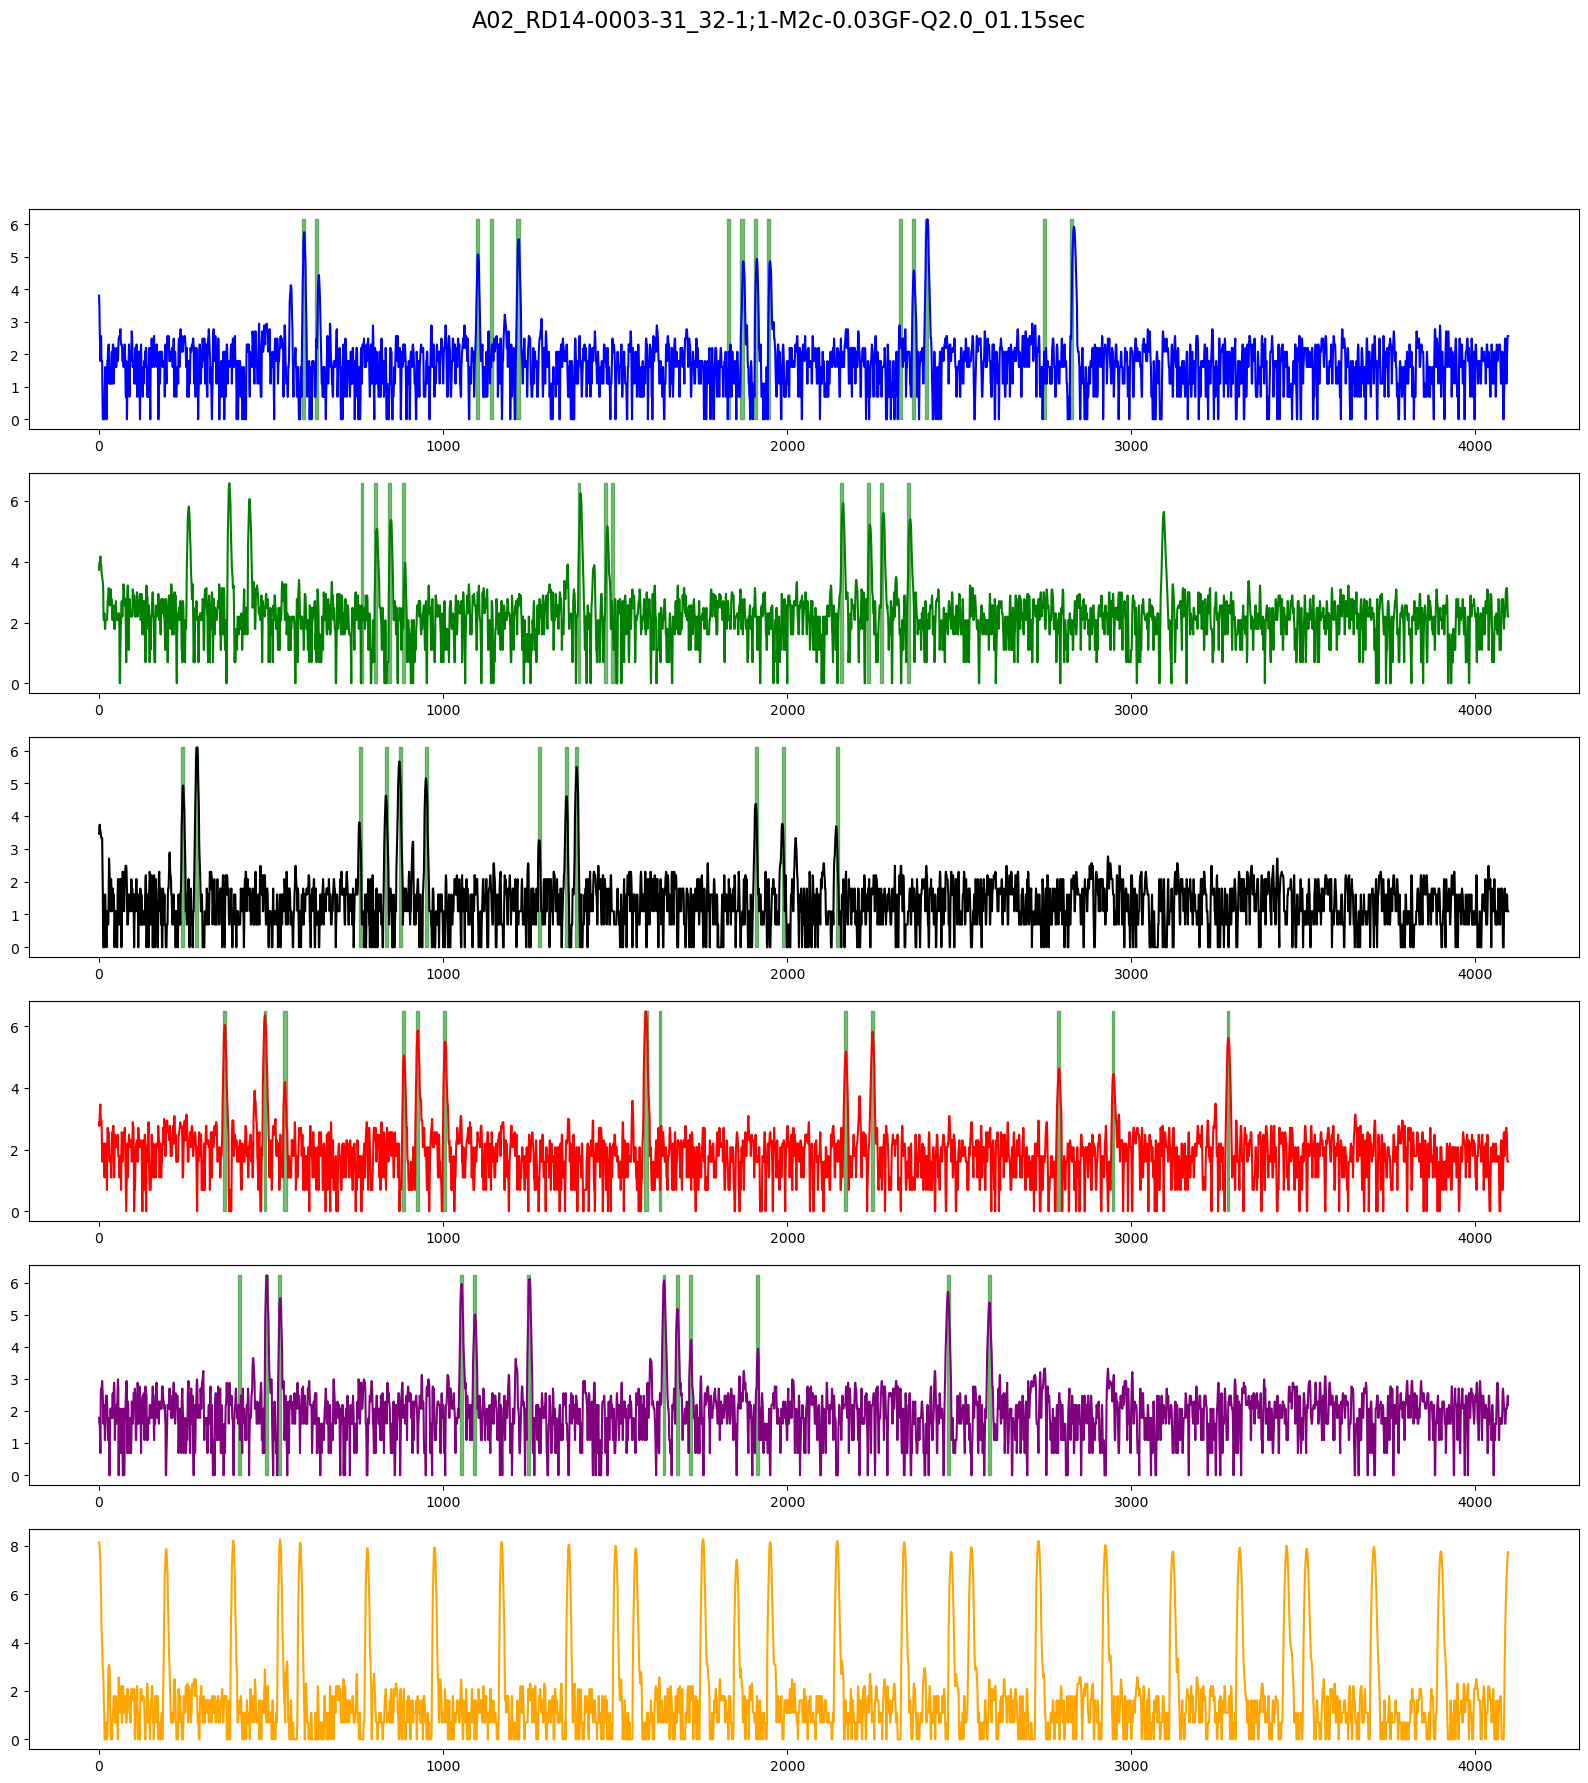

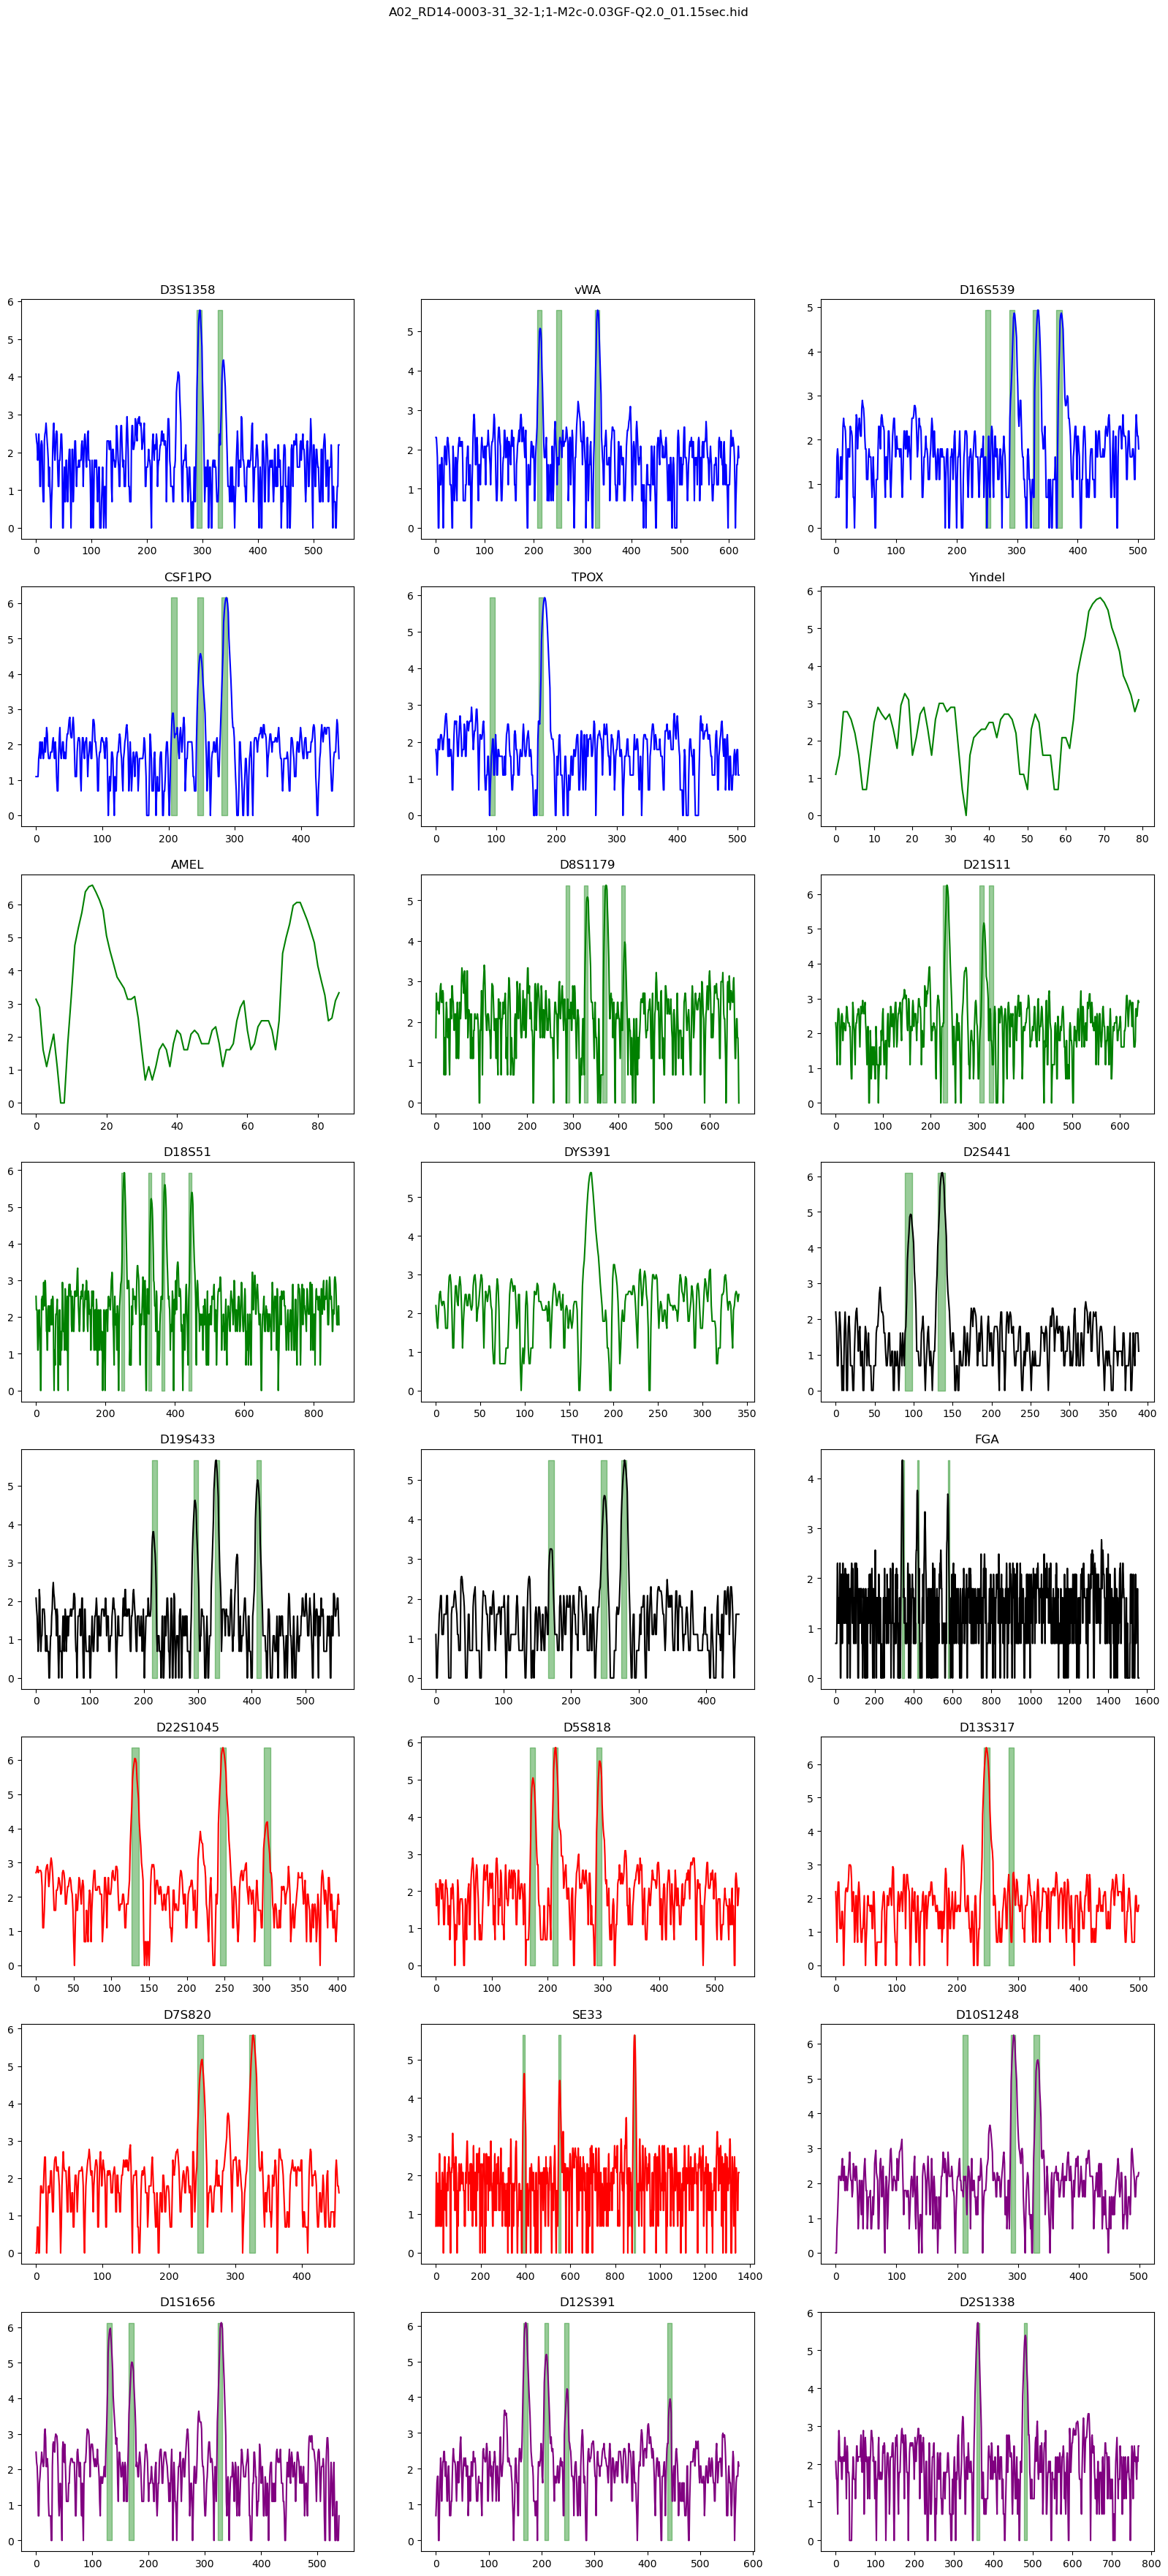

In [12]:
image.data = preprocessing_steps.fit_transform(image.data)
plot_profile(hid_images=[image])
plot_profile_markers(hid_images=[image])